In [1]:
# python -m venv .venv_gnn311
# source .venv_gnn\Scripts\Activate

# python -m pip install --upgrade pip setuptools wheel

# python -m pip install torch==2.5.1+cpu torchvision==0.20.1+cpu torchaudio==2.5.1+cpu --index-url https://download.pytorch.org/whl/cpu
# python -m pip install torch-geometric==2.6.1 pandas numpy scikit-learn matplotlib seaborn ipykernel

# python -m ipykernel install --user --name carbs-gnn311 --display-name "Python (carbs-gnn311)"


In [2]:
import sys, torch, torch_geometric
print(sys.version)
print(sys.executable)
print(torch.__version__)
print(torch_geometric.__version__)


3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]
c:\Users\c00551157\Desktop\ULL\Workspace\carbohydrates\.venv_gnn311\Scripts\python.exe
2.5.1+cpu
2.6.1


# Residue Classification with GNN (GraphSAGE -> GCN)

Goal:
1. Building graph from Jaccard similarity matrix.
2. Using key-frequency vectors as node features.
3. Training GraphSAGE first, then GCN.
4. Comparing classification performance.


In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch import nn

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GCNConv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("torch:", torch.__version__)


torch: 2.5.1+cpu


In [4]:
features_path = r"C:\Users\c00551157\Desktop\ULL\Workspace\carbohydrates\dnn\localFeatureVect_theta29_dist18_NoFeatureSelection_keyCombine0_header.csv"
jaccard_path = r"C:\Users\c00551157\Desktop\ULL\Workspace\carbohydrates\jaccard_similarity\theta29_dist18\jaccard_similarity.h5_res_csv\generalised.csv"

assert os.path.exists(features_path), features_path
assert os.path.exists(jaccard_path), jaccard_path
print("Paths OK")


Paths OK


## Step 1: Loading data

- Feature file: node features (key frequencies).
- Jaccard file: node-node similarity matrix in custom format:
  `protein_name;v1,v2,...,vN`


In [5]:
# Loading feature table + jaccard matri
feat_df = pd.read_csv(features_path)
feat_df = feat_df.rename(columns={feat_df.columns[0]: "Protein Name"})

def load_jaccard_generalised(path):
    names = []
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            name, values = line.split(";")
            vals = np.array([float(x) for x in values.split(",")], dtype=np.float32)
            names.append(name)
            rows.append(vals)
    S = np.vstack(rows)
    return names, S

j_names, S = load_jaccard_generalised(jaccard_path)

print("Feature shape:", feat_df.shape)
print("Similarity shape:", S.shape)
print("Similarity min/max/mean:", S.min(), S.max(), S.mean())


Feature shape: (254, 880)
Similarity shape: (254, 254)
Similarity min/max/mean: 0.0 0.898 0.68573654


In [6]:
# Aligning and creating labels
n = len(j_names)
assert S.shape == (n, n), "Jaccard matrix must be square"

feat_map = feat_df.set_index("Protein Name")
missing = [x for x in j_names if x not in feat_map.index]
assert len(missing) == 0, f"Missing feature rows: {len(missing)}"

feat_df = feat_map.loc[j_names].reset_index()

labels_str = np.array([name.split("_")[-1] for name in j_names])
le = LabelEncoder()
y = le.fit_transform(labels_str)

print("Classes:", le.classes_)
print(pd.Series(labels_str).value_counts())


Classes: ['BGC' 'MAN' 'NAG' 'YZT']
NAG    92
MAN    81
YZT    45
BGC    36
Name: count, dtype: int64


C:\Users\c00551157\AppData\Local\Temp\ipykernel_14020\3422495899.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat_df = feat_map.loc[j_names].reset_index()


In [7]:
# Anti-leak cleaning + feature preprocessing
import hashlib

def row_hash(a: np.ndarray) -> str:
    return hashlib.md5(np.ascontiguousarray(a).tobytes()).hexdigest()

# Hash on raw count features
X_raw_all = feat_df.drop(columns=["Protein Name"]).values.astype(np.float32)
row_hashes = np.array([row_hash(r) for r in X_raw_all])

# Remove exact duplicates with same (hash, label)
tmp = pd.DataFrame({
    "idx": np.arange(len(j_names)),
    "hash": row_hashes,
    "label": labels_str,
})
keep_idx = tmp.drop_duplicates(subset=["hash", "label"], keep="first")["idx"].to_numpy()

removed = len(j_names) - len(keep_idx)
if removed > 0:
    feat_df = feat_df.iloc[keep_idx].reset_index(drop=True)
    S = S[np.ix_(keep_idx, keep_idx)]
    j_names = [j_names[i] for i in keep_idx]
    labels_str = np.array([labels_str[i] for i in keep_idx])

# Recompute labels and sizes after cleaning
n = len(j_names)
le = LabelEncoder()
y = le.fit_transform(labels_str)

# Recompute hashes on cleaned rows
X_raw_all = feat_df.drop(columns=["Protein Name"]).values.astype(np.float32)
row_hashes = np.array([row_hash(r) for r in X_raw_all])

# Standard preprocessing for model input
X_log = np.log1p(X_raw_all)
scaler = StandardScaler()
X = scaler.fit_transform(X_log).astype(np.float32)

print(f"Removed duplicate rows: {removed}")
print("Cleaned n:", n)
print("Unique feature-hash groups:", len(np.unique(row_hashes)))
print("X:", X.shape, "y:", y.shape)


Removed duplicate rows: 12
Cleaned n: 242
Unique feature-hash groups: 242
X: (242, 879) y: (242,)


## Step 2: Building train/val/test split (Leakage-safe)

We split by **feature hash groups** so exact duplicate vectors cannot appear across train/val/test.


In [8]:
# Leakage-safe split: group by exact feature-hash
idx = np.arange(n)
groups = row_hashes
unique_groups = np.unique(groups)

if len(unique_groups) >= 3:
    from sklearn.model_selection import GroupShuffleSplit
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
    train_val_idx, test_idx = next(gss1.split(idx, y, groups=groups))

    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
    tr_rel, va_rel = next(gss2.split(train_val_idx, y[train_val_idx], groups=groups[train_val_idx]))
    train_idx = train_val_idx[tr_rel]
    val_idx = train_val_idx[va_rel]
    split_mode = "grouped_by_feature_hash"
else:
    train_val_idx, test_idx = train_test_split(
        idx, test_size=0.20, random_state=SEED, stratify=y
    )
    train_idx, val_idx = train_test_split(
        train_val_idx, test_size=0.25, random_state=SEED, stratify=y[train_val_idx]
    )
    split_mode = "stratified_fallback"

train_set, val_set, test_set = set(train_idx.tolist()), set(val_idx.tolist()), set(test_idx.tolist())
assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)

print("Split mode:", split_mode)
print("Train/Val/Test:", len(train_idx), len(val_idx), len(test_idx))

h_train = set(row_hashes[train_idx].tolist())
h_test = set(row_hashes[test_idx].tolist())
print("Exact duplicate hash overlap train-test:", len(h_train.intersection(h_test)))

for name, subset in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    cls, cnt = np.unique(y[subset], return_counts=True)
    mapping = {le.classes_[c]: int(k) for c, k in zip(cls, cnt)}
    print(name, mapping)


Split mode: grouped_by_feature_hash
Train/Val/Test: 144 49 49
Exact duplicate hash overlap train-test: 0
train {np.str_('BGC'): 18, np.str_('MAN'): 56, np.str_('NAG'): 49, np.str_('YZT'): 21}
val {np.str_('BGC'): 7, np.str_('MAN'): 9, np.str_('NAG'): 22, np.str_('YZT'): 11}
test {np.str_('BGC'): 5, np.str_('MAN'): 13, np.str_('NAG'): 20, np.str_('YZT'): 11}


## Step 3: Building graph edges from Jaccard

Matrix is dense, so keeping only top-k neighbors per node.
This avoids noisy weak edges and over-smoothing.


In [9]:
# Creating edge_index/edge_weight
k = 10  # can be modified 5, 10, 15

A = np.zeros_like(S, dtype=np.float32)
for i in range(n):
    nbrs = np.argsort(S[i])[-(k + 1):]  # includes self
    for j in nbrs:
        if i != j:
            A[i, j] = S[i, j]

# make undirected
A = np.maximum(A, A.T)

src, dst = np.where(A > 0)
edge_weight = A[src, dst]

edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long)
edge_weight = torch.tensor(edge_weight, dtype=torch.float32)

print("Num edges:", edge_index.shape[1])


Num edges: 4872


In [10]:
# Building PyG Data object
x_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.long)

train_mask = torch.zeros(n, dtype=torch.bool)
val_mask = torch.zeros(n, dtype=torch.bool)
test_mask = torch.zeros(n, dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data = Data(
    x=x_t,
    edge_index=edge_index,
    edge_weight=edge_weight,
    y=y_t,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask
)

data


Data(x=[242, 879], edge_index=[2, 4872], y=[242], edge_weight=[4872], train_mask=[242], val_mask=[242], test_mask=[242])

## Split Diagnostics (Important)

Even with clean node splits, this is still a **transductive graph** because train and test nodes are connected.
The diagnostics below show how many edges cross split boundaries.

High cross-split connectivity can inflate performance; report this in your results.

In [11]:
# Edge boundary diagnostics
src_np = data.edge_index[0].cpu().numpy()
dst_np = data.edge_index[1].cpu().numpy()

# For undirected stats, keep one direction only
undirected_mask = src_np < dst_np
u = src_np[undirected_mask]
v = dst_np[undirected_mask]

train_m = data.train_mask.cpu().numpy()
val_m = data.val_mask.cpu().numpy()
test_m = data.test_mask.cpu().numpy()

def count_edges(mask_a, mask_b):
    return int(np.sum((mask_a[u] & mask_b[v]) | (mask_b[u] & mask_a[v])))

counts = {
    'train-train': int(np.sum(train_m[u] & train_m[v])),
    'val-val': int(np.sum(val_m[u] & val_m[v])),
    'test-test': int(np.sum(test_m[u] & test_m[v])),
    'train-val': count_edges(train_m, val_m),
    'train-test': count_edges(train_m, test_m),
    'val-test': count_edges(val_m, test_m),
}

counts_df = pd.DataFrame([counts]).T.reset_index()
counts_df.columns = ['edge_type', 'count']
counts_df

,edge_type,count
0,train-train,908
1,val-val,134
2,test-test,61
3,train-val,659
4,train-test,471
5,val-test,203


In [12]:
# Training/evaluation utilities
def train_one_epoch(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_weight)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    out = model(data.x, data.edge_index, data.edge_weight)
    pred = out.argmax(dim=1).cpu().numpy()
    y_true = data.y.cpu().numpy()
    m = mask.cpu().numpy()
    acc = accuracy_score(y_true[m], pred[m])
    f1 = f1_score(y_true[m], pred[m], average="macro")
    return acc, f1, pred

def fit_model(model, data, lr=0.01, weight_decay=5e-4, max_epochs=400, patience=50):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_state = None
    best_val_f1 = -1
    wait = 0
    history = {"train_loss": [], "val_f1": []}

    for epoch in range(1, max_epochs + 1):
        loss = train_one_epoch(model, data, optimizer)
        _, val_f1, _ = evaluate(model, data, data.val_mask)

        history["train_loss"].append(loss)
        history["val_f1"].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | loss={loss:.4f} | val_f1={val_f1:.4f}")

        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return history, best_val_f1


## Step 4: GraphSAGE (first model)

GraphSAGE aggregates neighbor information and is good for inductive-style settings.


In [13]:
class GraphSAGEModel(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.35):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight=None):
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.conv2(h, edge_index)
        return h

sage = GraphSAGEModel(
    in_dim=data.x.shape[1],
    hidden_dim=64,
    out_dim=len(le.classes_),
    dropout=0.35
)

sage_hist, sage_best_val_f1 = fit_model(sage, data)
print("GraphSAGE best val macro-F1:", round(sage_best_val_f1, 4))


Epoch 001 | loss=1.4621 | val_f1=0.3750
Epoch 020 | loss=0.0056 | val_f1=1.0000
Epoch 040 | loss=0.0010 | val_f1=1.0000
Early stopping at epoch 56
GraphSAGE best val macro-F1: 1.0


In [14]:
# GraphSAGE test results
sage_test_acc, sage_test_f1, sage_pred = evaluate(sage, data, data.test_mask)
print("GraphSAGE Test Accuracy:", round(sage_test_acc, 4))
print("GraphSAGE Test Macro-F1:", round(sage_test_f1, 4))

y_true = data.y.cpu().numpy()[data.test_mask.cpu().numpy()]
y_pred = sage_pred[data.test_mask.cpu().numpy()]
print(classification_report(y_true, y_pred, target_names=le.classes_))


GraphSAGE Test Accuracy: 1.0
GraphSAGE Test Macro-F1: 1.0
              precision    recall  f1-score   support

         BGC       1.00      1.00      1.00         5
         MAN       1.00      1.00      1.00        13
         NAG       1.00      1.00      1.00        20
         YZT       1.00      1.00      1.00        11

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49



## Step 5: GCN (second model)

GCN uses normalized neighborhood aggregation and is a strong baseline.


In [15]:
class GCNModel(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.35):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight=None):
        h = self.conv1(x, edge_index, edge_weight=edge_weight)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.conv2(h, edge_index, edge_weight=edge_weight)
        return h

gcn = GCNModel(
    in_dim=data.x.shape[1],
    hidden_dim=64,
    out_dim=len(le.classes_),
    dropout=0.35
)

gcn_hist, gcn_best_val_f1 = fit_model(gcn, data)
print("GCN best val macro-F1:", round(gcn_best_val_f1, 4))


Epoch 001 | loss=1.6047 | val_f1=0.4906
Epoch 020 | loss=0.4441 | val_f1=0.8645
Epoch 040 | loss=0.7381 | val_f1=0.7259
Epoch 060 | loss=0.2354 | val_f1=0.8645
Epoch 080 | loss=0.1929 | val_f1=0.8574
Early stopping at epoch 81
GCN best val macro-F1: 0.9412


In [16]:
gcn_test_acc, gcn_test_f1, gcn_pred = evaluate(gcn, data, data.test_mask)
print("GCN Test Accuracy:", round(gcn_test_acc, 4))
print("GCN Test Macro-F1:", round(gcn_test_f1, 4))

y_true = data.y.cpu().numpy()[data.test_mask.cpu().numpy()]
y_pred = gcn_pred[data.test_mask.cpu().numpy()]
print(classification_report(y_true, y_pred, target_names=le.classes_))


GCN Test Accuracy: 0.9796
GCN Test Macro-F1: 0.9791
              precision    recall  f1-score   support

         BGC       1.00      1.00      1.00         5
         MAN       1.00      0.92      0.96        13
         NAG       1.00      1.00      1.00        20
         YZT       0.92      1.00      0.96        11

    accuracy                           0.98        49
   macro avg       0.98      0.98      0.98        49
weighted avg       0.98      0.98      0.98        49



In [17]:
#  Comparing both models
results = pd.DataFrame([
    {"Model": "GraphSAGE", "Test_Accuracy": sage_test_acc, "Test_MacroF1": sage_test_f1},
    {"Model": "GCN",       "Test_Accuracy": gcn_test_acc,  "Test_MacroF1": gcn_test_f1},
])

results


,Model,Test_Accuracy,Test_MacroF1
0,GraphSAGE,1.000000,1.00000
1,GCN,0.979592,0.97913


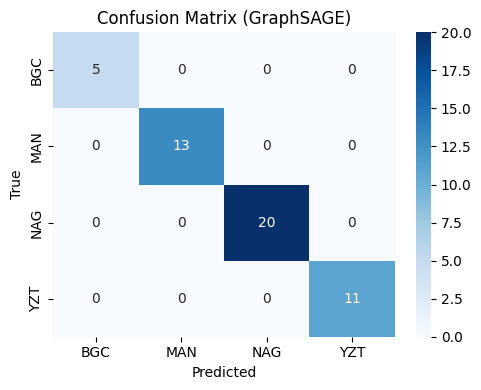

In [18]:
# Confusion matrix for best model
best_name = "GraphSAGE" if sage_test_f1 >= gcn_test_f1 else "GCN"
best_pred = sage_pred if best_name == "GraphSAGE" else gcn_pred

m = data.test_mask.cpu().numpy()
yt = data.y.cpu().numpy()[m]
yp = best_pred[m]

cm = confusion_matrix(yt, yp)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix ({best_name})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## Optional Robustness Check (Multiple Seeds)

Running a short multi-seed experiment to verify the model is not lucky on one split.
This keeps the same split/graph and only varies initialization and optimizer randomness.

In [19]:
def run_with_seed(model_cls, model_kwargs, data, seed, max_epochs=180, patience=35):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    model = model_cls(**model_kwargs)
    _, _ = fit_model(model, data, max_epochs=max_epochs, patience=patience)
    test_acc, test_f1, _ = evaluate(model, data, data.test_mask)
    return test_acc, test_f1

model_grid = [
    ('GraphSAGE', GraphSAGEModel, dict(in_dim=data.x.shape[1], hidden_dim=64, out_dim=len(le.classes_), dropout=0.35)),
    ('GCN', GCNModel, dict(in_dim=data.x.shape[1], hidden_dim=64, out_dim=len(le.classes_), dropout=0.35)),
]

seeds = [7, 21, 42, 84, 123]
rows = []
for model_name, model_cls, kwargs in model_grid:
    for s in seeds:
        acc, f1 = run_with_seed(model_cls, kwargs, data, seed=s)
        rows.append({'model': model_name, 'seed': s, 'test_acc': acc, 'test_macro_f1': f1})

seed_df = pd.DataFrame(rows)
summary = seed_df.groupby('model')[['test_acc', 'test_macro_f1']].agg(['mean', 'std']).round(4)
print('Per-seed results:')
display(seed_df)
print('Summary (mean/std):')
display(summary)

Epoch 001 | loss=1.8279 | val_f1=0.4935
Epoch 020 | loss=0.1957 | val_f1=1.0000
Epoch 040 | loss=0.0009 | val_f1=1.0000
Early stopping at epoch 46
Epoch 001 | loss=1.4760 | val_f1=0.3750
Epoch 020 | loss=0.0433 | val_f1=1.0000
Epoch 040 | loss=0.0001 | val_f1=1.0000
Early stopping at epoch 45
Epoch 001 | loss=1.4621 | val_f1=0.3750
Epoch 020 | loss=0.0056 | val_f1=1.0000
Epoch 040 | loss=0.0010 | val_f1=1.0000
Early stopping at epoch 41
Epoch 001 | loss=1.6219 | val_f1=0.3750
Epoch 020 | loss=0.0382 | val_f1=0.9676
Epoch 040 | loss=0.0002 | val_f1=1.0000
Early stopping at epoch 43
Epoch 001 | loss=1.7082 | val_f1=0.4885
Epoch 020 | loss=0.1597 | val_f1=1.0000
Epoch 040 | loss=0.0042 | val_f1=1.0000
Early stopping at epoch 46
Epoch 001 | loss=1.3186 | val_f1=0.4885
Epoch 020 | loss=0.3962 | val_f1=0.7583
Epoch 040 | loss=0.2288 | val_f1=0.8645
Early stopping at epoch 58
Epoch 001 | loss=1.3784 | val_f1=0.4935
Epoch 020 | loss=0.5530 | val_f1=0.7259
Epoch 040 | loss=0.4671 | val_f1=0.829

,model,seed,test_acc,test_macro_f1
0,GraphSAGE,7,1.000000,1.000000
1,GraphSAGE,21,1.000000,1.000000
2,GraphSAGE,42,1.000000,1.000000
3,GraphSAGE,84,1.000000,1.000000
4,GraphSAGE,123,0.979592,0.962963
5,GCN,7,0.795918,0.706746
6,GCN,21,0.877551,0.820789
7,GCN,42,0.897959,0.839031
8,GCN,84,0.979592,0.962963
9,GCN,123,0.918367,0.867934


Summary (mean/std):


test_acc         test_macro_f1        
              mean     std          mean     std
model                                           
GCN         0.8939  0.0668        0.8395  0.0922
GraphSAGE   0.9959  0.0091        0.9926  0.0166

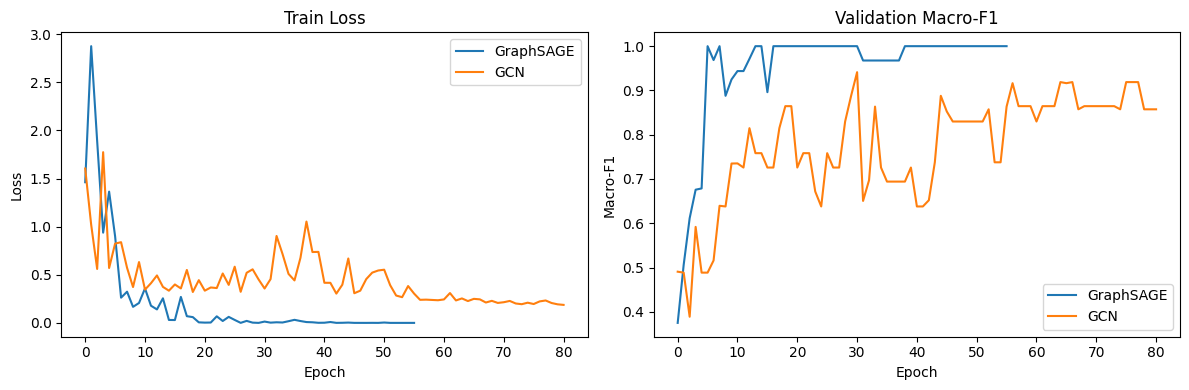

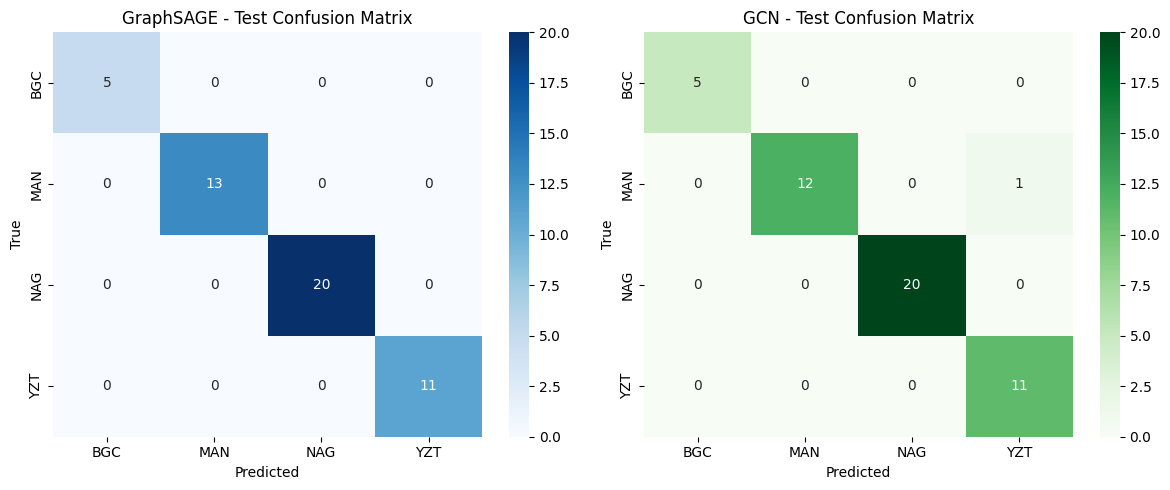

GraphSAGE report:
              precision    recall  f1-score   support

         BGC       1.00      1.00      1.00         5
         MAN       1.00      1.00      1.00        13
         NAG       1.00      1.00      1.00        20
         YZT       1.00      1.00      1.00        11

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49

GCN report:
              precision    recall  f1-score   support

         BGC       1.00      1.00      1.00         5
         MAN       1.00      0.92      0.96        13
         NAG       1.00      1.00      1.00        20
         YZT       0.92      1.00      0.96        11

    accuracy                           0.98        49
   macro avg       0.98      0.98      0.98        49
weighted avg       0.98      0.98      0.98        49



In [20]:
# Drawing training curves + confusion matrices for GraphSAGE and GCN

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def get_test_outputs(model, data):
    _, _, pred_all = evaluate(model, data, data.test_mask)
    m = data.test_mask.cpu().numpy()
    y_true = data.y.cpu().numpy()[m]
    y_pred = pred_all[m]
    cm = confusion_matrix(y_true, y_pred)
    return y_true, y_pred, cm

# 1) Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sage_hist["train_loss"], label="GraphSAGE")
axes[0].plot(gcn_hist["train_loss"], label="GCN")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(sage_hist["val_f1"], label="GraphSAGE")
axes[1].plot(gcn_hist["val_f1"], label="GCN")
axes[1].set_title("Validation Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].legend()

plt.tight_layout()
plt.show()

# 2) Confusion matrices
sage_y_true, sage_y_pred, sage_cm = get_test_outputs(sage, data)
gcn_y_true, gcn_y_pred, gcn_cm = get_test_outputs(gcn, data)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    sage_cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0]
)
axes[0].set_title("GraphSAGE - Test Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    gcn_cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1]
)
axes[1].set_title("GCN - Test Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

# 3) Optional: classification reports
print("GraphSAGE report:")
print(classification_report(sage_y_true, sage_y_pred, target_names=le.classes_))

print("GCN report:")
print(classification_report(gcn_y_true, gcn_y_pred, target_names=le.classes_))


Nodes: 242 Edges: 2436


C:\Users\c00551157\AppData\Local\Temp\ipykernel_14020\2098817005.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", num_classes)


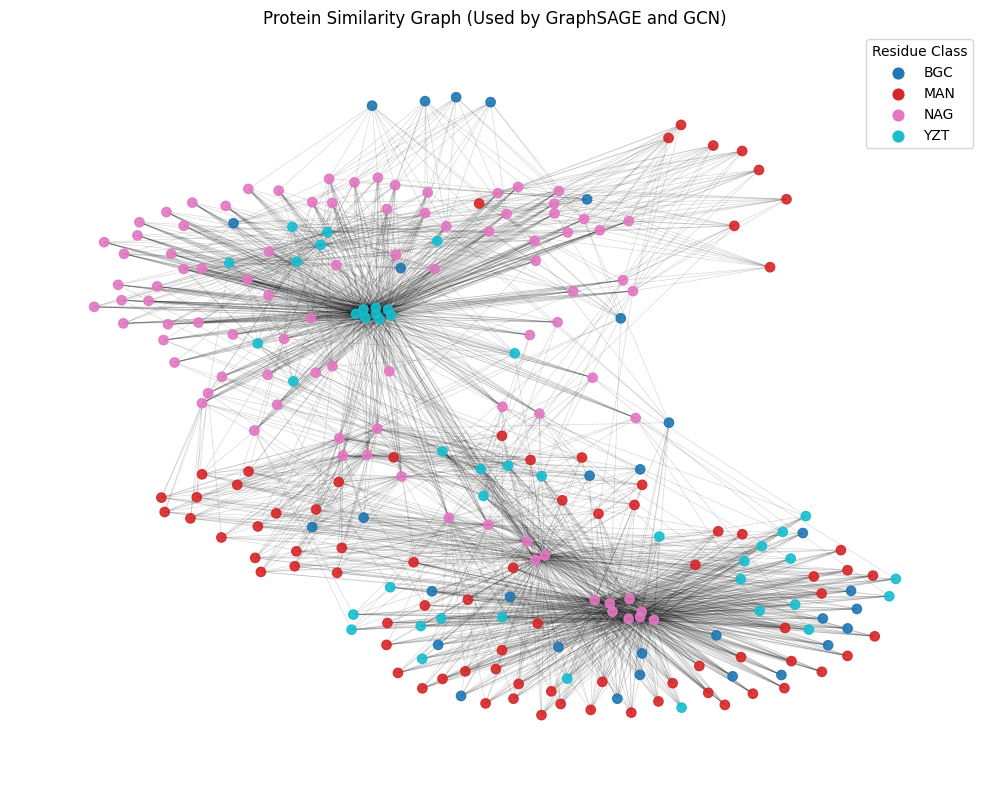

In [21]:
# Network topology visualization (same graph used by GraphSAGE and GCN)

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Build undirected edge list from data.edge_index
ei = data.edge_index.cpu().numpy()
src, dst = ei[0], ei[1]

# keep one direction only to avoid duplicate undirected edges
mask = src < dst
u = src[mask]
v = dst[mask]

G = nx.Graph()
G.add_nodes_from(range(data.num_nodes))
G.add_edges_from(zip(u.tolist(), v.tolist()))

print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

# Color nodes by class label
y_np = data.y.cpu().numpy()
num_classes = len(le.classes_)
cmap = plt.cm.get_cmap("tab10", num_classes)
node_colors = [cmap(int(c)) for c in y_np]

# Layout (can take a bit of time)
pos = nx.spring_layout(G, seed=42, k=0.35)

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.5)
nx.draw_networkx_nodes(G, pos, node_size=45, node_color=node_colors, alpha=0.9)

# Legend
for i, cls in enumerate(le.classes_):
    plt.scatter([], [], color=cmap(i), label=cls, s=60)
plt.legend(title="Residue Class", loc="best")

plt.title("Protein Similarity Graph (Used by GraphSAGE and GCN)")
plt.axis("off")
plt.tight_layout()
plt.show()


Subgraph nodes: 233 edges: 2337


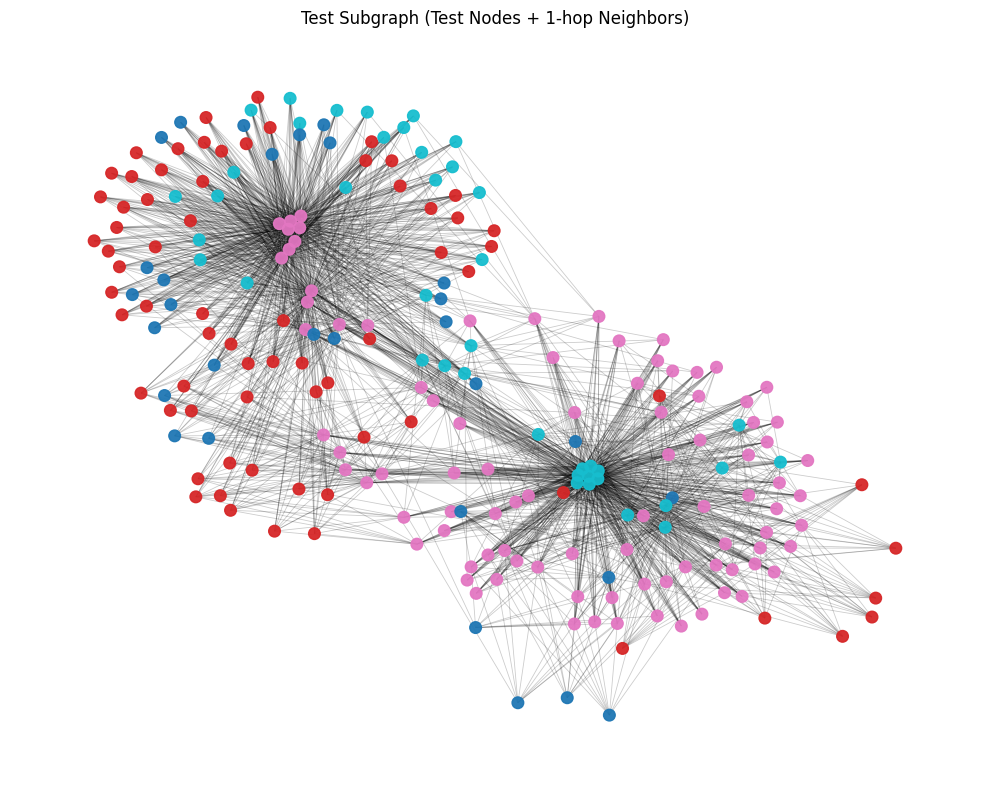

In [22]:
# Optional: show only test nodes + their 1-hop neighbors (clearer view)

test_nodes = set(np.where(data.test_mask.cpu().numpy())[0].tolist())
neighbors = set()

for s, d in zip(src, dst):
    if s in test_nodes:
        neighbors.add(d)
    if d in test_nodes:
        neighbors.add(s)

sub_nodes = sorted(test_nodes.union(neighbors))
H = G.subgraph(sub_nodes).copy()

print("Subgraph nodes:", H.number_of_nodes(), "edges:", H.number_of_edges())

sub_colors = [cmap(int(y_np[n])) for n in H.nodes()]
pos_h = nx.spring_layout(H, seed=42, k=0.45)

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(H, pos_h, alpha=0.2, width=0.6)
nx.draw_networkx_nodes(H, pos_h, node_size=70, node_color=sub_colors, alpha=0.95)

plt.title("Test Subgraph (Test Nodes + 1-hop Neighbors)")
plt.axis("off")
plt.tight_layout()
plt.show()


Picked test nodes: 2
Subgraph nodes: 15 edges: 22


C:\Users\c00551157\AppData\Local\Temp\ipykernel_14020\1260638673.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", num_classes)


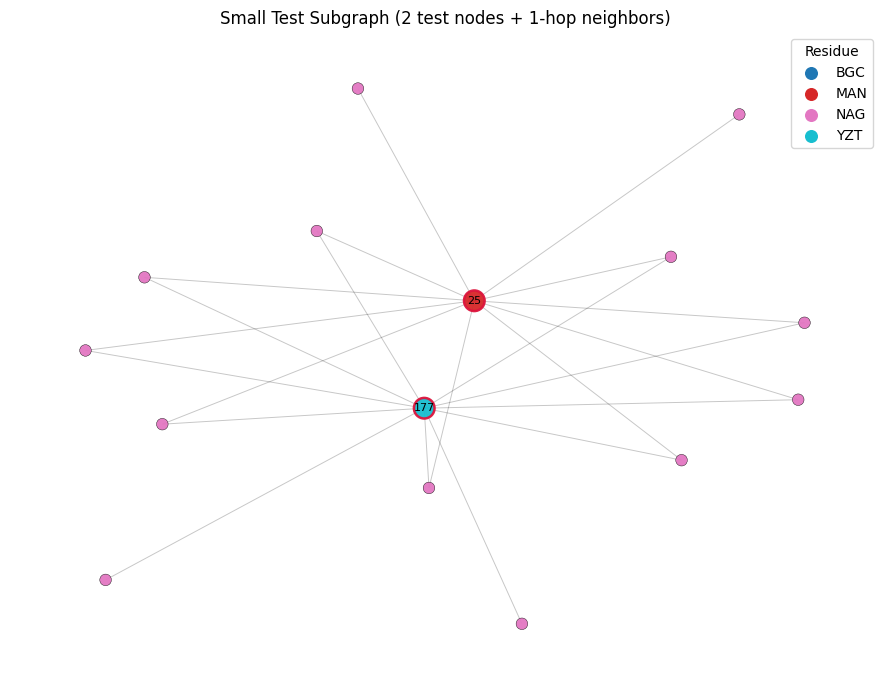

In [23]:
# Smaller visualization: picking only a few test nodes and show their 1-hop neighborhood

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# how many test nodes to show
NUM_TEST_TO_SHOW = 2   # change to 5, 10, etc.

# optional: fix randomness for reproducibility
rng = np.random.default_rng(42)

test_idx_all = np.where(data.test_mask.cpu().numpy())[0]
picked_test = rng.choice(test_idx_all, size=min(NUM_TEST_TO_SHOW, len(test_idx_all)), replace=False)
picked_test = set(picked_test.tolist())

# collect 1-hop neighbors
neighbors = set()
ei = data.edge_index.cpu().numpy()
src, dst = ei[0], ei[1]
for s, d in zip(src, dst):
    if s in picked_test:
        neighbors.add(d)
    if d in picked_test:
        neighbors.add(s)

sub_nodes = sorted(picked_test.union(neighbors))
H = G.subgraph(sub_nodes).copy()  # G from previous cell

print("Picked test nodes:", len(picked_test))
print("Subgraph nodes:", H.number_of_nodes(), "edges:", H.number_of_edges())

# style
y_np = data.y.cpu().numpy()
num_classes = len(le.classes_)
cmap = plt.cm.get_cmap("tab10", num_classes)
node_colors = [cmap(int(y_np[n])) for n in H.nodes()]

# highlight picked test nodes
node_sizes = [220 if n in picked_test else 70 for n in H.nodes()]
edge_colors = ["crimson" if n in picked_test else "black" for n in H.nodes()]
line_widths = [1.8 if n in picked_test else 0.3 for n in H.nodes()]

pos = nx.spring_layout(H, seed=42, k=0.55)

plt.figure(figsize=(9, 7))
nx.draw_networkx_edges(H, pos, alpha=0.22, width=0.7)
nx.draw_networkx_nodes(
    H, pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors=edge_colors,
    linewidths=line_widths,
    alpha=0.95
)

# optional labels only for picked test nodes
nx.draw_networkx_labels(
    H, pos,
    labels={n: str(n) for n in picked_test},
    font_size=8
)

for i, cls in enumerate(le.classes_):
    plt.scatter([], [], color=cmap(i), label=cls, s=70)
plt.legend(title="Residue", loc="best")

plt.title(f"Small Test Subgraph ({len(picked_test)} test nodes + 1-hop neighbors)")
plt.axis("off")
plt.tight_layout()
plt.show()


C:\Users\c00551157\AppData\Local\Temp\ipykernel_14020\1794692522.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", num_classes)


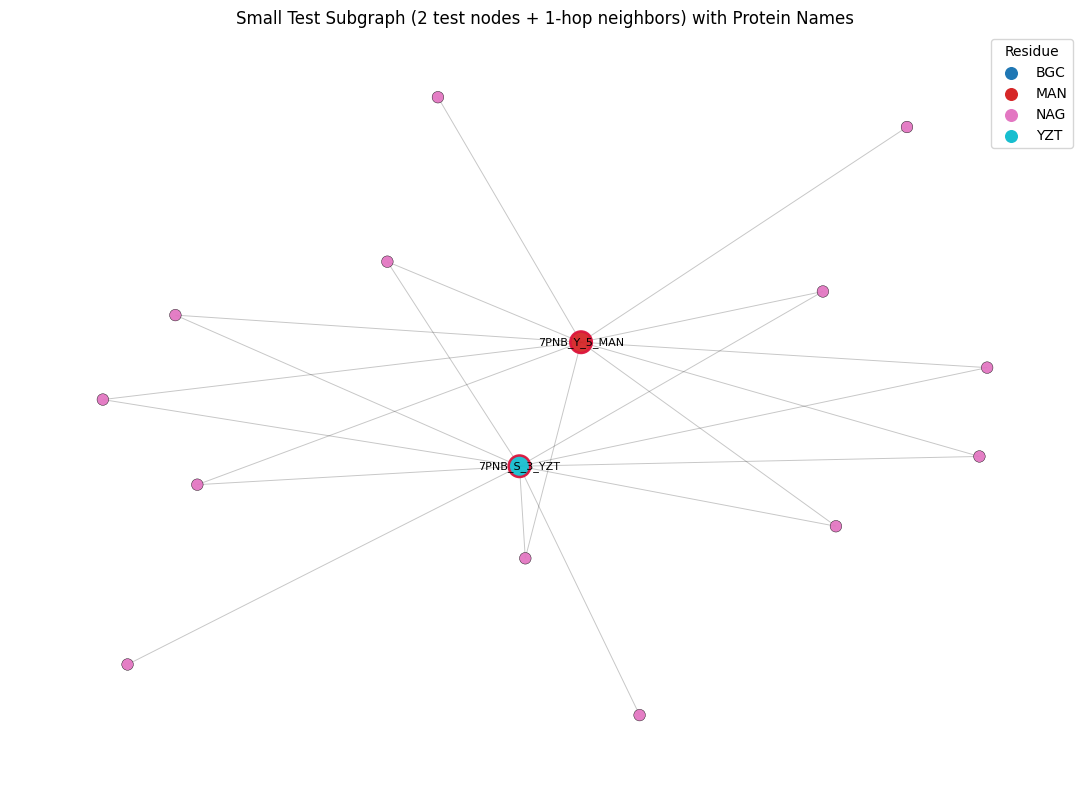

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

y_np = data.y.cpu().numpy()
num_classes = len(le.classes_)
cmap = plt.cm.get_cmap("tab10", num_classes)

ei = data.edge_index.cpu().numpy()
src, dst = ei[0], ei[1]

neighbors = set()
for s, d in zip(src, dst):
    if s in picked_test:
        neighbors.add(d)
    if d in picked_test:
        neighbors.add(s)

sub_nodes = sorted(set(picked_test).union(neighbors))
H = G.subgraph(sub_nodes).copy()

node_colors = [cmap(int(y_np[n])) for n in H.nodes()]
node_sizes = [240 if n in picked_test else 70 for n in H.nodes()]
edge_colors = ["crimson" if n in picked_test else "black" for n in H.nodes()]
line_widths = [1.8 if n in picked_test else 0.3 for n in H.nodes()]

pos = nx.spring_layout(H, seed=42, k=0.55)

plt.figure(figsize=(11, 8))
nx.draw_networkx_edges(H, pos, alpha=0.22, width=0.7)
nx.draw_networkx_nodes(
    H, pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors=edge_colors,
    linewidths=line_widths,
    alpha=0.95
)

# Label only picked test nodes with full protein names
labels = {n: j_names[n] for n in picked_test}
nx.draw_networkx_labels(H, pos, labels=labels, font_size=8)

for i, cls in enumerate(le.classes_):
    plt.scatter([], [], color=cmap(i), label=cls, s=70)
plt.legend(title="Residue", loc="best")

plt.title(f"Small Test Subgraph ({len(picked_test)} test nodes + 1-hop neighbors) with Protein Names")
plt.axis("off")
plt.tight_layout()
plt.show()


C:\Users\c00551157\AppData\Local\Temp\ipykernel_14020\662302335.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", num_classes)


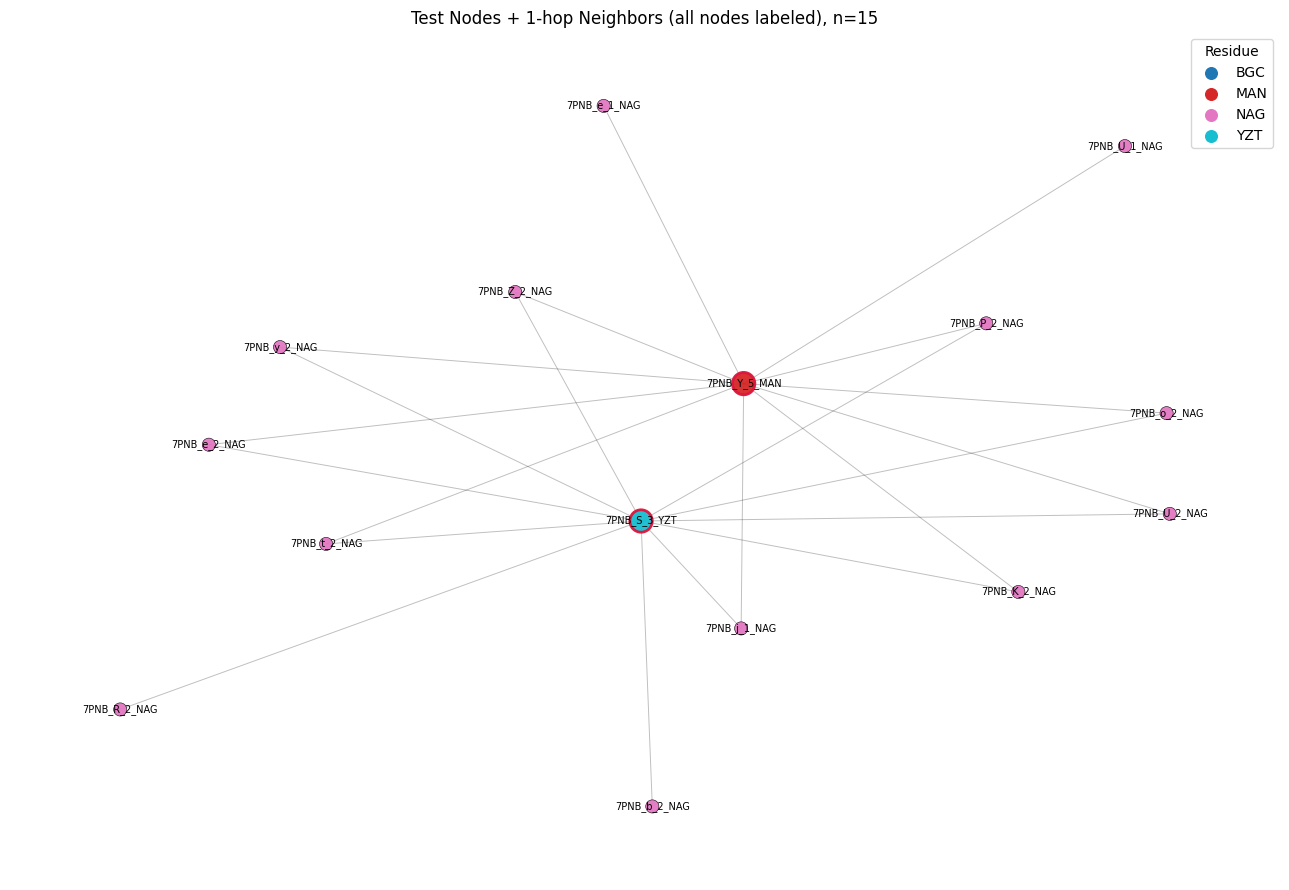

In [25]:
# Label test nodes + all associated 1-hop neighbor nodes with protein names

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

# assumes: data, G, le, j_names, picked_test already exist
y_np = data.y.cpu().numpy()
num_classes = len(le.classes_)
cmap = plt.cm.get_cmap("tab10", num_classes)

# Build subgraph: picked test nodes + 1-hop neighbors
ei = data.edge_index.cpu().numpy()
src, dst = ei[0], ei[1]

neighbors = set()
for s, d in zip(src, dst):
    if s in picked_test:
        neighbors.add(d)
    if d in picked_test:
        neighbors.add(s)

sub_nodes = sorted(set(picked_test).union(neighbors))
H = G.subgraph(sub_nodes).copy()

# Visual styles
node_colors = [cmap(int(y_np[n])) for n in H.nodes()]
node_sizes = [260 if n in picked_test else 90 for n in H.nodes()]
edge_colors = ["crimson" if n in picked_test else "black" for n in H.nodes()]
line_widths = [2.0 if n in picked_test else 0.4 for n in H.nodes()]

pos = nx.spring_layout(H, seed=42, k=0.62)

plt.figure(figsize=(13, 9))
nx.draw_networkx_edges(H, pos, alpha=0.25, width=0.7)
nx.draw_networkx_nodes(
    H, pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors=edge_colors,
    linewidths=line_widths,
    alpha=0.95
)

# Label EVERY node in this small subgraph with protein name
# Use shorter labels to reduce clutter; switch to full j_names[n] if you prefer
labels = {n: j_names[n] for n in H.nodes()}
nx.draw_networkx_labels(H, pos, labels=labels, font_size=7)

for i, cls in enumerate(le.classes_):
    plt.scatter([], [], color=cmap(i), label=cls, s=70)
plt.legend(title="Residue", loc="best")

plt.title(f"Test Nodes + 1-hop Neighbors (all nodes labeled), n={H.number_of_nodes()}")
plt.axis("off")
plt.tight_layout()
plt.show()


In [26]:
# Top-10 most similar neighbors for each picked test node (from Jaccard matrix S)
import pandas as pd
import numpy as np

TOPK = 10
rows = []

for n in sorted(picked_test):
    sims = S[n].copy()
    sims[n] = -1.0  # exclude self
    top_idx = np.argsort(sims)[-TOPK:][::-1]
    for rank, j in enumerate(top_idx, start=1):
        rows.append({
            "test_node_id": n,
            "test_protein": j_names[n],
            "rank": rank,
            "neighbor_id": int(j),
            "neighbor_protein": j_names[j],
            "jaccard_similarity": float(S[n, j]),
        })

top10_df = pd.DataFrame(rows).sort_values(["test_node_id", "rank"])
top10_df


,test_node_id,test_protein,rank,neighbor_id,neighbor_protein,jaccard_similarity
0,25,7PNB_Y_5_MAN,1,46,7PNB_y_2_NAG,0.847
1,25,7PNB_Y_5_MAN,2,4,7PNB_t_2_NAG,0.845
2,25,7PNB_Y_5_MAN,3,18,7PNB_e_2_NAG,0.842
3,25,7PNB_Y_5_MAN,4,99,7PNB_o_2_NAG,0.842
4,25,7PNB_Y_5_MAN,5,168,7PNB_Z_2_NAG,0.842
5,25,7PNB_Y_5_MAN,6,1,7PNB_P_2_NAG,0.842
6,25,7PNB_Y_5_MAN,7,10,7PNB_U_2_NAG,0.840
7,25,7PNB_Y_5_MAN,8,159,7PNB_K_2_NAG,0.840
8,25,7PNB_Y_5_MAN,9,171,7PNB_j_1_NAG,0.832
9,25,7PNB_Y_5_MAN,10,6,7PNB_U_1_NAG,0.830


In [27]:
# Optional: pretty print grouped output
for n in sorted(picked_test):
    sub = top10_df[top10_df["test_node_id"] == n][
        ["rank", "neighbor_protein", "jaccard_similarity"]
    ]
    print(f"\nTest node {n} | {j_names[n]}")
    print(sub.to_string(index=False))



Test node 25 | 7PNB_Y_5_MAN
 rank neighbor_protein  jaccard_similarity
    1     7PNB_y_2_NAG               0.847
    2     7PNB_t_2_NAG               0.845
    3     7PNB_e_2_NAG               0.842
    4     7PNB_o_2_NAG               0.842
    5     7PNB_Z_2_NAG               0.842
    6     7PNB_P_2_NAG               0.842
    7     7PNB_U_2_NAG               0.840
    8     7PNB_K_2_NAG               0.840
    9     7PNB_j_1_NAG               0.832
   10     7PNB_U_1_NAG               0.830

Test node 177 | 7PNB_S_3_YZT
 rank neighbor_protein  jaccard_similarity
    1     7PNB_y_2_NAG               0.872
    2     7PNB_t_2_NAG               0.872
    3     7PNB_K_2_NAG               0.869
    4     7PNB_P_2_NAG               0.867
    5     7PNB_U_2_NAG               0.867
    6     7PNB_Z_2_NAG               0.867
    7     7PNB_e_2_NAG               0.865
    8     7PNB_o_2_NAG               0.865
    9     7PNB_b_2_NAG               0.840
   10     7PNB_j_1_NAG               0

In [28]:
# 1) Check what split mode you actually got
print("split_mode =", split_mode)
print("unique pdb groups =", len(np.unique([n.split('_')[0] for n in j_names])))


split_mode = grouped_by_feature_hash
unique pdb groups = 2


In [ ]:
# 2) Check exact duplicate feature rows crossing train/test
import hashlib

def row_hash(a):
    return hashlib.md5(np.ascontiguousarray(a).tobytes()).hexdigest()

h = np.array([row_hash(r) for r in X])  # X after preprocessing
train_h = set(h[train_idx])
test_h = set(h[test_idx])
dup_cross = train_h.intersection(test_h)
print("Exact duplicate feature vectors train<->test:", len(dup_cross))


Exact duplicate feature vectors train<->test: 0


In [30]:
import hashlib
import numpy as np
import pandas as pd

def row_hash(a: np.ndarray) -> str:
    return hashlib.md5(np.ascontiguousarray(a).tobytes()).hexdigest()

# Rebuild full aligned table from source files (before dedup)
feat_full = pd.read_csv(features_path).rename(columns={pd.read_csv(features_path).columns[0]: "Protein Name"})

# reload jaccard names to preserve notebook order
j_names_full, _S_full = load_jaccard_generalised(jaccard_path)

feat_map = feat_full.set_index("Protein Name")
feat_full = feat_map.loc[j_names_full].reset_index()

labels_full = np.array([n.split("_")[-1] for n in j_names_full])
X_raw_full = feat_full.drop(columns=["Protein Name"]).values.astype(np.float32)
hashes_full = np.array([row_hash(r) for r in X_raw_full])

df = pd.DataFrame({
    "orig_idx": np.arange(len(j_names_full)),
    "protein_name": j_names_full,
    "label": labels_full,
    "hash": hashes_full
})

# duplicates by (hash,label): keep first, mark rest as removed
df["keep"] = ~df.duplicated(subset=["hash", "label"], keep="first")
kept = df[df["keep"]].copy()
removed = df[~df["keep"]].copy()

# map each removed row -> kept representative
rep = kept[["hash", "label", "orig_idx", "protein_name"]].rename(columns={
    "orig_idx": "kept_idx",
    "protein_name": "kept_protein_name"
})
removed_map = removed.merge(rep, on=["hash", "label"], how="left")

print("Removed rows:", len(removed_map))
display(removed_map.sort_values(["label", "kept_idx", "orig_idx"]))


Removed rows: 12


C:\Users\c00551157\AppData\Local\Temp\ipykernel_14020\1452046213.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat_full = feat_map.loc[j_names_full].reset_index()


,orig_idx,protein_name,label,hash,keep,kept_idx,kept_protein_name
1,78,7PNB_w_4_BGC,BGC,64cf9387b841f4759bafc02904d84581,False,36,7PNB_N_4_BGC
7,187,7PNB_h_4_BGC,BGC,64cf9387b841f4759bafc02904d84581,False,36,7PNB_N_4_BGC
11,232,7PNB_X_4_BGC,BGC,64cf9387b841f4759bafc02904d84581,False,36,7PNB_N_4_BGC
9,199,7PNB_S_4_BGC,BGC,7fae27a48643530e7ff8180bc525c955,False,104,7PNB_m_4_BGC
8,195,7PNB_b_4_BGC,BGC,25dc0b4c5a3eb51c641d78a2bca507f6,False,126,7PNB_q_4_BGC
6,186,7PNB_c_4_BGC,BGC,520b016ef51b2fc3ae442f8fbe922c63,False,141,7PNB_r_4_BGC
5,181,7PNB_h_6_MAN,MAN,adc008b67a1b7099463fb31e6fe7da13,False,16,7PNB_N_6_MAN
10,213,7PNB_x_5_MAN,MAN,557d3dbd1522982f15264039c40c8554,False,116,7PNB_O_5_MAN
3,156,7PNB_X_5_MAN,MAN,d0e8f788fbd29f0cdf4b11e3b65cdde4,False,153,7PNB_S_5_MAN
0,26,7PNB_j_2_NAG,NAG,c7940d74c6c7578b7f1224cd6111f598,False,10,7PNB_U_2_NAG


In [31]:
removed_map.groupby("label").size().sort_values(ascending=False)


label
BGC    6
MAN    3
YZT    2
NAG    1
dtype: int64